In [73]:
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt

repo_root = Path.cwd().parent.parent.parent
sys.path.insert(0, str(repo_root))

import SysSimX
from SysSimX.utilities.units import ureg
from SysSimX.components.fmu_comp import FMUComponent

repo_root = Path.cwd().parent
sys.path.insert(0, str(repo_root))
from MyModels.FEM.fem_pendulum import FEMPendulum
from MyModels.OpenSim.opensim_pendulum import OpenSimPendulum

In [74]:
# Instantiate the pendulum models
fmu_pendulum_path = Path.cwd() / 'FMUs/Pendulum.fmu'
eqb_pendulum = FMUComponent(name="EQB_Pendulum", fmu_path=fmu_pendulum_path)

fem_pendulum = FEMPendulum(name="FEM_Pendulum")

opensim_pendulum = OpenSimPendulum(name="OpenSim_Pendulum")

In [75]:
# Initialize FEM Pendulum as Master and set EQB and OpenSim Parameters correspondingly
t0 = 0.0

t = 0.0
dt = 0.01
t_end = 5

fem_pendulum._use_gravity  = False
fem_pendulum._with_contact = False
fem_pendulum.anim_params.animate = False
fem_pendulum.sim_params.t_end = t_end
fem_pendulum.initialize(t0)

q0 = np.deg2rad(fem_pendulum.init_params.angular_position_deg)
omega0 = fem_pendulum.init_params.angular_velocity

mass = fem_pendulum.mass
inertia = fem_pendulum.inertia
corresponding_length = np.sqrt(inertia / mass)

# Set OpenSim Parameters and initialize
opensim_pendulum.parameters['InitialConditions']['q0'] = q0
opensim_pendulum.parameters['InitialConditions']['omega0'] = omega0
opensim_pendulum.parameters['Model']['mass'] = mass
opensim_pendulum.parameters['Model']['length'] = corresponding_length
opensim_pendulum._use_gravity  = fem_pendulum._use_gravity
opensim_pendulum._with_contact = fem_pendulum._with_contact 
opensim_pendulum.initialize(t0)

# Set EQB Parameters and initialize
eqb_pendulum.parameters['q0'].start = q0
eqb_pendulum.parameters['omega0'].start = omega0
eqb_pendulum.parameters['m'].start = mass
eqb_pendulum.parameters['L'].start = corresponding_length
eqb_pendulum.parameters['g'].start = 0.0 if not fem_pendulum._use_gravity else 9.81
eqb_pendulum.initialize(t0)

print(f"Mass:    {mass:.4f} kg")
print(f"Length:  {corresponding_length:.4f} m")
print(f"inertia: {inertia:.4f} kg m²")


Mass:    121.2496 kgLOG_SOLVER        | info    | CVODE linear multistep method CV_BDF
LOG_SOLVER        | info    | CVODE maximum integration order CV_ITER_NEWTON
LOG_SOLVER        | info    | CVODE use equidistant time grid YES
LOG_SOLVER        | info    | CVODE Using relative error tolerance 1.000000e-06
LOG_SOLVER        | info    | CVODE Using dense internal linear solver SUNLinSol_Dense.
LOG_SOLVER        | info    | CVODE Use internal dense numeric jacobian method.
LOG_SOLVER        | info    | CVODE uses internal root finding method NO
LOG_SOLVER        | info    | CVODE maximum absolut step size 0
LOG_SOLVER        | info    | CVODE initial step size is set automatically
LOG_SOLVER        | info    | CVODE maximum integration order 5
LOG_SOLVER        | info    | CVODE maximum number of nonlinear convergence failures permitted during one step 10
LOG_SOLVER        | info    | CVODE BDF stability limit detection algorithm OFF

Length:  0.6732 m
inertia: 54.9510 kg m²


In [76]:
fem_pendulum.setup_simulation_diagnostics()

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

In [77]:
# Analytical solution
I = fem_pendulum.inertia
m = fem_pendulum.mass
q0 = np.deg2rad(fem_pendulum.init_params.angular_position_deg)
omega0 = fem_pendulum.init_params.angular_velocity

# q(t+1) = q(t) + omega(t)*dt + 0.5*alpha(t)*dt^2
def analytic_step(dt, q, omega, torque, I):
    alpha = torque / I
    q_next = q + omega * dt + 0.5 * alpha * dt**2
    omega_next = omega + alpha * dt
    return q_next, omega_next, alpha

def determine_torque(t, t_end, torque=1.0):
    interval = t_end / 6 
    if t < interval:
        return t * torque
    elif t < 2 * interval:
        return interval * torque
    elif t < 3 * interval:
        return interval * torque - (t - 2 * interval) * torque
    elif t < 4 * interval:
        return -(t - 3 * interval) * torque
    elif t < 5 * interval:
        return -(interval) * torque
    else:
        return -interval * torque + (t - 5 * interval) * torque

In [78]:
input_torque = 40 # Nm

t_vals = []
torque_vals = {"EQB": [], "FEM": [], "OpenSim": []}
alpha_vals = {"EQB": [], "FEM": [], "OpenSim": []}
omega_vals = {"EQB": [], "FEM": [], "OpenSim": []}
q_vals = {"EQB": [], "FEM": [], "OpenSim": []}

t_an_vals = [t]
q_an_vals = [q0]
omega_an_vals = [omega0]
alpha_an_vals = [0.0]
torque_an_vals = [0.0]

q_an = q0
omega_an = omega0

while t < t_end:
    # Determine input torque
    torque = determine_torque(t, t_end, input_torque)
    torque_an_vals.append(torque)

    # Compute analytical solution
    q_an, omega_an, alpha_an = analytic_step(dt, q_an, omega_an, torque, I)

    # Set input torque for Models
    eqb_pendulum.set_inputs({'torque': torque}, t=t)
    fem_pendulum.set_inputs({'torque': torque}, t=t)
    opensim_pendulum.set_inputs({'torque': torque}, t=t)

    # Do simulation step
    eqb_pendulum.do_step(t, dt)
    fem_pendulum.do_step(t, dt)
    opensim_pendulum.do_step(t, dt)

    # Get outputs
    eqb_res = eqb_pendulum.get_outputs()
    fem_res = fem_pendulum.get_outputs()
    opensim_res = opensim_pendulum.get_outputs()

    torque_eqb = eqb_pendulum.get_state()['torque']['value']
    torque_fem = fem_pendulum.get_state()['torque']['value']
    torque_opensim = opensim_pendulum.get_state()['torque']['value']

    t += dt
    
    # Store outputs
    t_vals.append(t)
    
    torque_vals["EQB"].append(torque_eqb)
    alpha_vals["EQB"].append(eqb_res['alpha'].magnitude)
    omega_vals["EQB"].append(eqb_res['omega'].magnitude)
    q_vals["EQB"].append(eqb_res['q'].magnitude)

    torque_vals["FEM"].append(torque_fem)
    alpha_vals["FEM"].append(fem_res['alpha'].magnitude)
    omega_vals["FEM"].append(fem_res['omega'].magnitude)
    q_vals["FEM"].append(fem_res['q'].magnitude)

    torque_vals["OpenSim"].append(torque_opensim)
    alpha_vals["OpenSim"].append(opensim_res['alpha'].magnitude)
    omega_vals["OpenSim"].append(opensim_res['omega'].magnitude)
    q_vals["OpenSim"].append(opensim_res['q'].magnitude)

    t_an_vals.append(t)
    q_an_vals.append(q_an)
    omega_an_vals.append(omega_an)
    alpha_an_vals.append(alpha_an)

In [103]:
marker_size = 4
fem_style = {'color': "#12e2d1", 'linestyle': '-', 'marker': 'None', 'markersize': marker_size, 'linewidth': 3.5}  # Deep blue
opensim_style = {'color': "#f8c20f", 'linestyle': '-', 'marker': 'None', 'markersize': marker_size, 'linewidth': 3.5}  # Green
eqb_style = {'color': "#1d8d43", 'linestyle': '-', 'marker': 'None', 'markersize': marker_size, 'linewidth': 3.5}  # Purple
fontdict = {'fontsize': 11, 'fontweight': 'bold'}

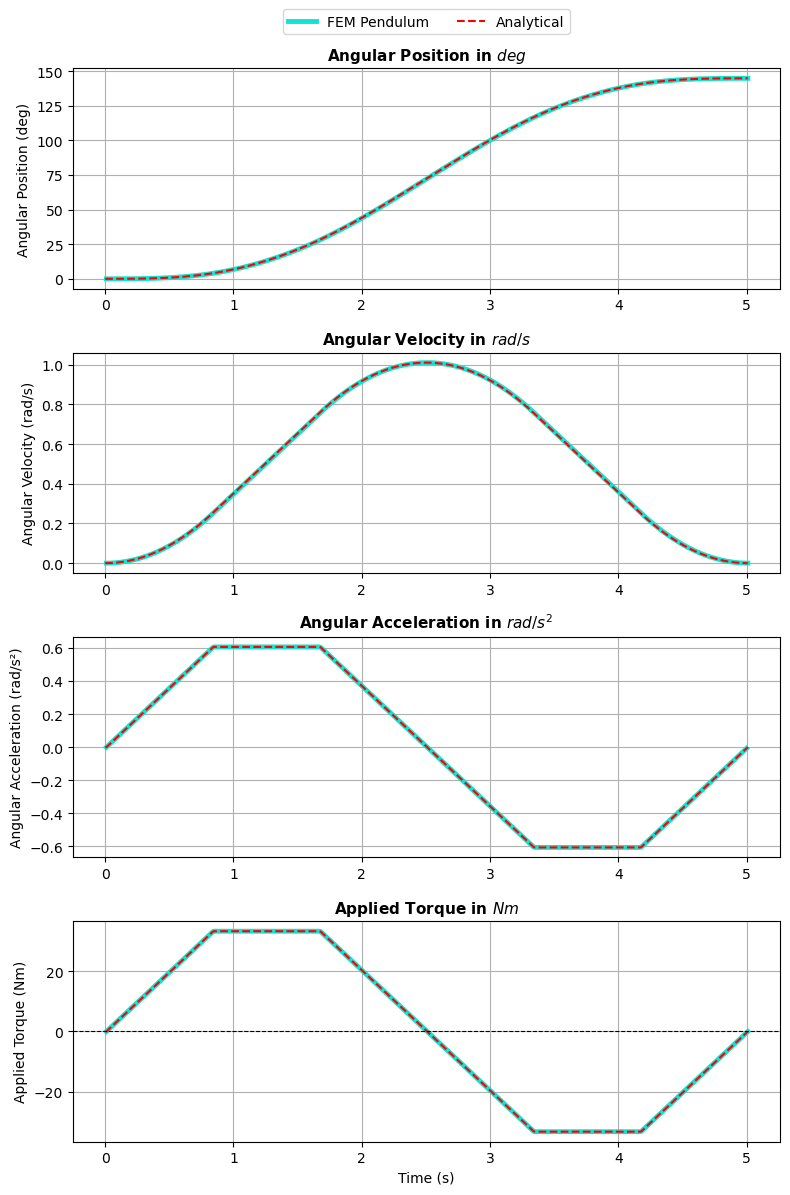

In [104]:
plt.figure(figsize=(8, 12))

plt.subplot(4,1,1).set_title("Angular Position in $deg$", **fontdict)
plt.plot(t_vals, np.rad2deg(q_vals["FEM"]), label="FEM Pendulum", **fem_style)
plt.plot(t_an_vals, np.rad2deg(q_an_vals), label="Analytical", color='red', linestyle='--')
plt.ylabel("Angular Position (deg)")
plt.grid(which='both')
plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.3), ncol=4)

plt.subplot(4,1,2).set_title("Angular Velocity in $rad/s$", **fontdict)
plt.plot(t_vals, omega_vals["FEM"], label="FEM Pendulum", **fem_style)
plt.plot(t_an_vals, omega_an_vals, label="Analytical", color='red', linestyle='--')
plt.ylabel("Angular Velocity (rad/s)")
plt.grid(which='both')

plt.subplot(4,1,3).set_title("Angular Acceleration in $rad/s^2$", **fontdict)
plt.plot(t_vals[:-1], alpha_vals["FEM"][:-1], label="FEM Pendulum", **fem_style)
plt.plot(t_an_vals, alpha_an_vals, label="Analytical", color='red', linestyle='--')
plt.ylabel("Angular Acceleration (rad/s²)")
plt.grid(which='both')

plt.subplot(4,1,4).set_title("Applied Torque in $Nm$", **fontdict)
plt.plot(t_vals, torque_vals["FEM"], label="FEM", **fem_style)
plt.plot(t_an_vals, torque_an_vals, label="Analytical", color='red', linestyle='--')
plt.axhline(0, color='k', linestyle='--', linewidth=0.8)
plt.ylabel("Applied Torque (Nm)")
plt.grid(which='both')

plt.xlabel("Time (s)")
plt.tight_layout()
plt.savefig("PendulumModelComparison_FEM.svg")
plt.show()

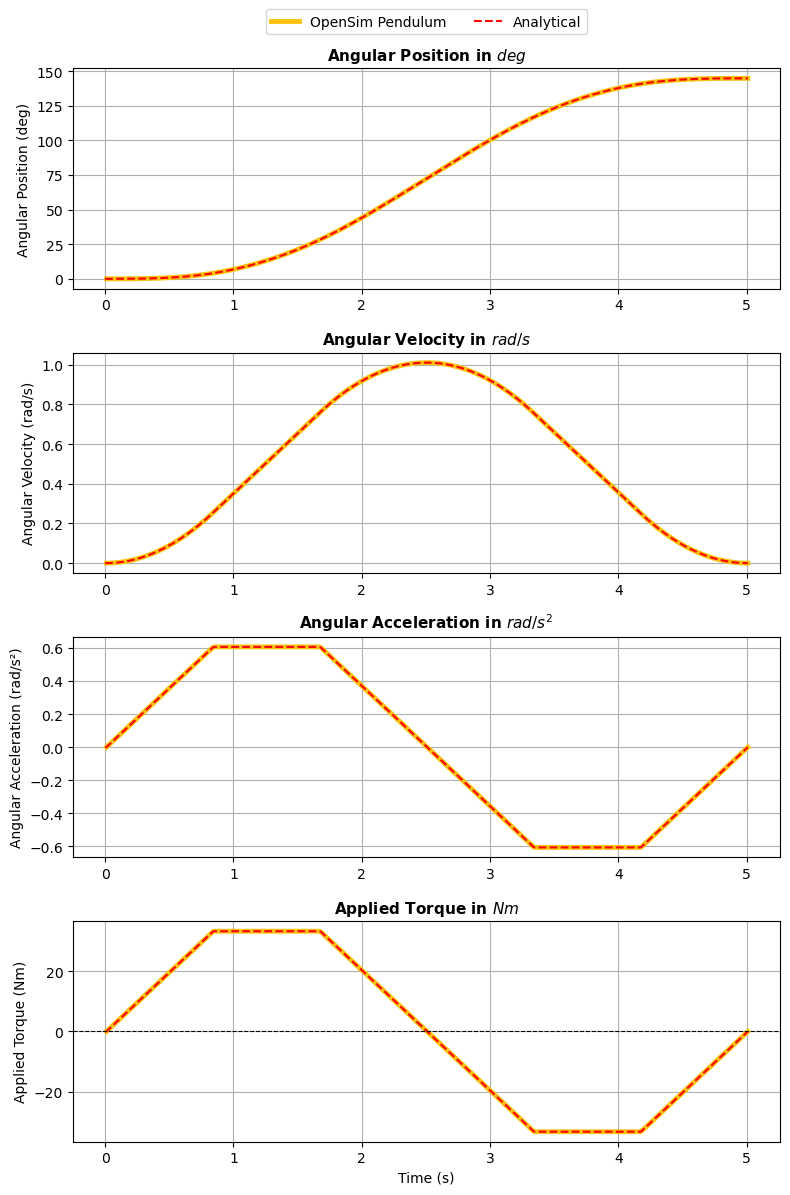

In [105]:
plt.figure(figsize=(8, 12))

plt.subplot(4,1,1).set_title("Angular Position in $deg$", **fontdict)
plt.plot(t_vals, np.rad2deg(q_vals["OpenSim"]), label="OpenSim Pendulum", **opensim_style)
plt.plot(t_an_vals, np.rad2deg(q_an_vals), label="Analytical", color='red', linestyle='--')
plt.ylabel("Angular Position (deg)")
plt.grid(which='both')
plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.3), ncol=4)

plt.subplot(4,1,2).set_title("Angular Velocity in $rad/s$", **fontdict)
plt.plot(t_vals, omega_vals["OpenSim"], label="OpenSim Pendulum", **opensim_style)
plt.plot(t_an_vals, omega_an_vals, label="Analytical", color='red', linestyle='--')
plt.ylabel("Angular Velocity (rad/s)")
plt.grid(which='both')

plt.subplot(4,1,3).set_title("Angular Acceleration in $rad/s^2$", **fontdict)
plt.plot(t_vals, alpha_vals["OpenSim"], label="OpenSim Pendulum", **opensim_style)
plt.plot(t_an_vals, alpha_an_vals, label="Analytical", color='red', linestyle='--')
plt.ylabel("Angular Acceleration (rad/s²)")
plt.grid(which='both')

plt.subplot(4,1,4).set_title("Applied Torque in $Nm$", **fontdict)
plt.plot(t_vals, torque_vals["OpenSim"], label="OpenSim", **opensim_style)
plt.plot(t_an_vals, torque_an_vals, label="Analytical", color='red', linestyle='--')
plt.axhline(0, color='k', linestyle='--', linewidth=0.8)
plt.ylabel("Applied Torque (Nm)")
plt.grid(which='both')

plt.xlabel("Time (s)")
plt.tight_layout()
plt.savefig("PendulumModelComparison_OpenSim.svg")
plt.show()

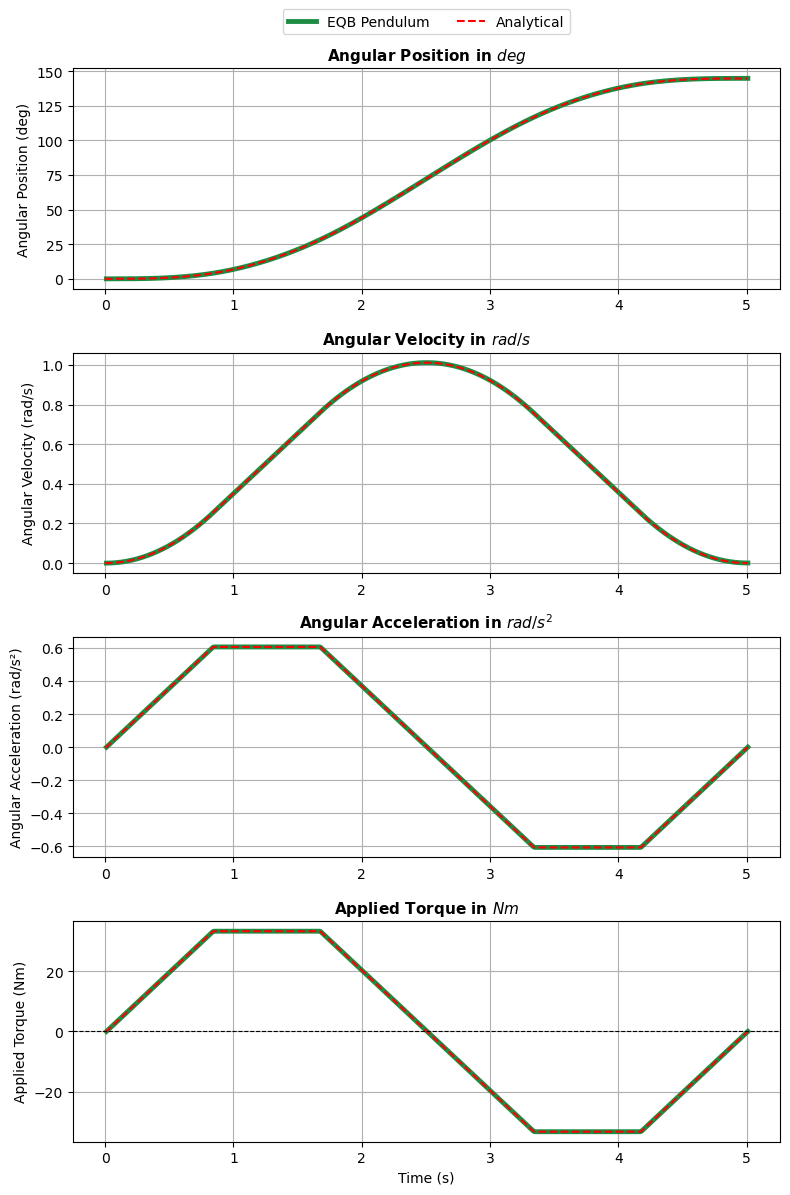

In [106]:
plt.figure(figsize=(8, 12))

plt.subplot(4,1,1).set_title("Angular Position in $deg$", **fontdict)
plt.plot(t_vals, np.rad2deg(q_vals["EQB"]), label="EQB Pendulum", **eqb_style)
plt.plot(t_an_vals, np.rad2deg(q_an_vals), label="Analytical", color='red', linestyle='--')
plt.ylabel("Angular Position (deg)")
plt.grid(which='both')
plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.3), ncol=4)

plt.subplot(4,1,2).set_title("Angular Velocity in $rad/s$", **fontdict)
plt.plot(t_vals, omega_vals["EQB"], label="EQB Pendulum", **eqb_style)
plt.plot(t_an_vals, omega_an_vals, label="Analytical", color='red', linestyle='--')
plt.ylabel("Angular Velocity (rad/s)")
plt.grid(which='both')

plt.subplot(4,1,3).set_title("Angular Acceleration in $rad/s^2$", **fontdict)
plt.plot(t_vals, alpha_vals["EQB"], label="EQB Pendulum", **eqb_style)
plt.plot(t_an_vals, alpha_an_vals, label="Analytical", color='red', linestyle='--')
plt.ylabel("Angular Acceleration (rad/s²)")
plt.grid(which='both')

plt.subplot(4,1,4).set_title("Applied Torque in $Nm$", **fontdict)
plt.plot(t_vals, torque_vals["EQB"], label="EQB", **eqb_style)
plt.plot(t_an_vals, torque_an_vals, label="Analytical", color='red', linestyle='--')
plt.axhline(0, color='k', linestyle='--', linewidth=0.8)
plt.ylabel("Applied Torque (Nm)")
plt.grid(which='both')

plt.xlabel("Time (s)")
plt.tight_layout()
plt.savefig("PendulumModelComparison_EQB.svg")
plt.show()